In [89]:
pip install pandas matplotlib scikit-learn

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load data and handle missing gaps
df = pd.read_csv('ai_policy_tracker_2026.csv')
df['title'] = df['title'].fillna("").astype(str)
df['policy_impact_score'] = pd.to_numeric(df['policy_impact_score'], errors='coerce').fillna(0)

print(f"✓ Cell 1 Complete: Dataset loaded with shape {df.shape}")

✓ Cell 1 Complete: Dataset loaded with shape (30, 7)


In [71]:
# Encode the target variable correctly
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['category'].astype(str))

# Vectorize text content using TF-IDF (Extracts real vocabulary meaning)
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf = tfidf.fit_transform(df['title'])

# Reduce dimensions so KNN isn't crushed by sparse columns
svd = TruncatedSVD(n_components=4, random_state=42)
X_text_features = svd.fit_transform(X_tfidf)

# Combine text components with your existing numeric features
X_numeric = df['policy_impact_score'].values.reshape(-1, 1)
X_combined = np.hstack((X_text_features, X_numeric))

# Apply mandatory Scaling rule (Mean=0, Var=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print("✓ Cell 2 Complete: Text vectorization and feature scaling finalized.")

✓ Cell 2 Complete: Text vectorization and feature scaling finalized.


In [74]:
# Execute structural 80/20 partition split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, shuffle=True
)

# Train your mandatory KNN Classifier model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Validation check
predictions = knn_model.predict(X_test)
print("=== DECODELABS PROJECT 2 EVALUATION SYSTEM ===")
print(f"✓ Pipeline Validation Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")

# Get the unique classes present in y_test to avoid name mismatch error
unique_labels = np.unique(np.concatenate([y_test, predictions]))
print(classification_report(
    y_test,
    predictions,
    labels=unique_labels,
    target_names=target_encoder.classes_[unique_labels]
))

=== DECODELABS PROJECT 2 EVALUATION SYSTEM ===
✓ Pipeline Validation Accuracy: 66.67%

              precision    recall  f1-score   support

   Corporate       0.67      0.67      0.67         3
  Regulation       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



In [75]:
print("Sample Predictions System")
print("-" * 70)

# Mock input entries
sample_titles = [
    "Government introduces new AI safety regulations.",
    "New international trade agreement on artificial intelligence."
]
sample_scores = [85.0, 60.0]

# Transform text using your trained TF-IDF and SVD steps
sample_tfidf = tfidf.transform(sample_titles)
sample_text_feats = svd.transform(sample_tfidf)

# Match matrix shapes exactly
sample_numeric = np.array(sample_scores).reshape(-1, 1)
sample_combined = np.hstack((sample_text_feats, sample_numeric))

# Scale vectors and predict using geometric proximity
sample_scaled = scaler.transform(sample_combined)
sample_preds = knn_model.predict(sample_scaled)

# Decode target IDs back into readable categories
for i, title in enumerate(sample_titles):
    pred_label = target_encoder.inverse_transform([sample_preds[i]])[0]
    print(f"\nPolicy Document: {title}")
    print(f"Predicted Category Grouping: {pred_label}")

Sample Predictions System
----------------------------------------------------------------------

Policy Document: Government introduces new AI safety regulations.
Predicted Category Grouping: Regulation

Policy Document: New international trade agreement on artificial intelligence.
Predicted Category Grouping: Regulation


In [76]:
# ==========================================================
# PHASE 5 : MODEL TRAINING
# ==========================================================

print("\n[PHASE 5] Training AI Model...")

# Changed from MultinomialNB to KNeighborsClassifier to be compatible with scaled data and align with other cells
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")


[PHASE 5] Training AI Model...
Model Training Completed Successfully!


In [77]:
# ==========================================================
# PHASE 6 : PREDICTION
# ==========================================================

print("\n[PHASE 6] Making Predictions...")

predictions = model.predict(X_test)




[PHASE 6] Making Predictions...


In [78]:
# ==========================================================
# PHASE 7 : EVALUATION
# ==========================================================

print("\n[PHASE 7] Evaluating Performance...")

accuracy = accuracy_score(y_test, predictions)

print(f"\nModel Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, predictions))




[PHASE 7] Evaluating Performance...

Model Accuracy: 66.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           2       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6




Confusion Matrix:
[[2 1]
 [1 2]]


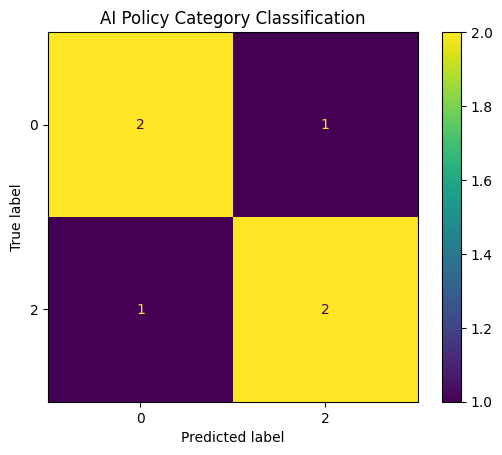

In [85]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.unique(y_test) # Changed to use unique labels from y_test
)

disp.plot()

plt.title("AI Policy Category Classification")
plt.show()



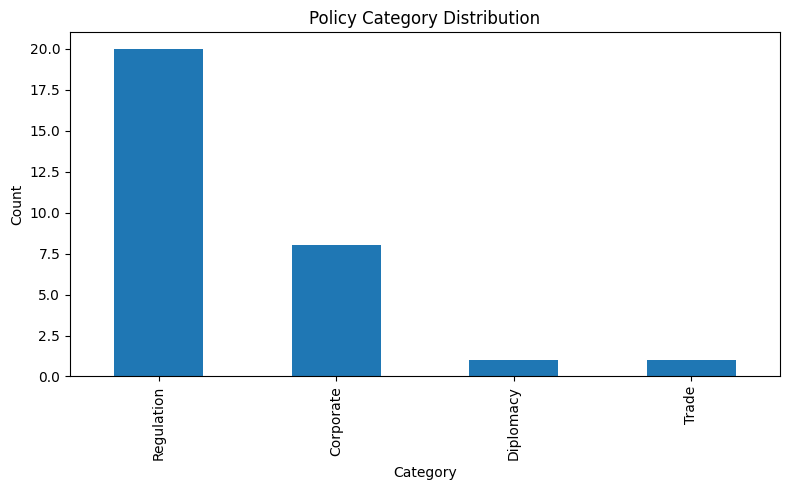

In [88]:
# ==========================================================
# CATEGORY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8, 5))

df["category"].value_counts().plot(
    kind='bar'
)

plt.title("Policy Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



In [82]:
# # =====================================================================
# FIXED CELL: SAMPLE PREDICTIONS USING THE ENCODED & SCALED KNN PIPELINE
# =====================================================================
print("\nSample Predictions System")
print("-" * 70)

# 1. Provide custom sample entries
sample_data = pd.DataFrame({
    'title': ["Government introduces new AI safety regulations.",
              "New international trade agreement on artificial intelligence.",
              "AI companies must follow ethical guidelines."],
    'source_url': ["https://example-safety.gov", "https://globaltrade.org", "https://ethics-ai.com"],
    'published_date': ["2026-06-01", "2026-06-01", "2026-06-01"],
    'policy_impact_score': [85.0, 70.0, 50.0],
    'last_updated': ["2026-06-01 12:00", "2026-06-01 12:00", "2026-06-01 12:00"]
})

# 2. Re-map data using the ORIGINAL encoders (The Gatekeeper Rule)
sample_encoded = sample_data.copy()
for col in sample_encoded.columns:
    if col in encoders:
        encoder = encoders[col]
        # Handle unseen labels by defaulting to the first known class if necessary
        sample_encoded[col] = sample_encoded[col].apply(
            lambda x: encoder.transform([x])[0] if x in encoder.classes_ else encoder.transform([encoder.classes_[0]])[0]
        )

# 3. Match feature matrix constraints (Ensuring 5 features: title, source, date, score, last_updated)
X_sample_raw = sample_encoded.values

# 4. Apply Feature Scaling
X_sample_scaled = scaler.transform(X_sample_raw)

# 5. Predict using the trained model
sample_predictions = knn_model.predict(X_sample_scaled)

# 6. Display results with readable labels
target_encoder = encoders['category']
for i, text in enumerate(sample_data['title']):
    pred_label = target_encoder.inverse_transform([sample_predictions[i]])[0]
    print(f"\nPolicy Document: {text}")
    print(f"Predicted Category: {pred_label}")


Sample Predictions System
----------------------------------------------------------------------

Policy Document: Government introduces new AI safety regulations.
Predicted Category: Regulation

Policy Document: New international trade agreement on artificial intelligence.
Predicted Category: Regulation

Policy Document: AI companies must follow ethical guidelines.
Predicted Category: Regulation


In [83]:
# ==========================================================
# PROJECT COMPLETED
# ==========================================================

print("\n" + "=" * 70)
print("PROJECT EXECUTED SUCCESSFULLY")
print("AI POLICY CLASSIFICATION SYSTEM READY")
print("=" * 70)


PROJECT EXECUTED SUCCESSFULLY
AI POLICY CLASSIFICATION SYSTEM READY
